# 07 · Comparación final de modelos
## Tesis UBA 2026 — LLMs vs. ML Clásico para Credit Scoring

Consolida las métricas de todos los modelos en una tabla única. La lógica vive en
`scripts/07_comparacion_final.py` (`compare_models`).

### Dos protocolos de evaluación (columna `eval_type`)
Los modelos no comparten exactamente el mismo protocolo, y la tabla lo explicita:
- **`test_temporal`** — métrica puntual sobre el test honesto (split por `set`). Es la
  métrica primaria. Disponible para todos en *total*, y para los LLM también por segmento.
- **`cv_temporal`** — media ± std del `TimeSeriesSplit` (notebook 05); aporta el desglose
  por segmento de los modelos clásicos con su variabilidad.

In [1]:
import importlib.util
from pathlib import Path

import pandas as pd
from IPython.display import Image


def _find_base() -> Path:
    base = Path.cwd()
    while not (base / "scripts").exists() and base != base.parent:
        base = base.parent
    return base


BASE = _find_base()


def load_script(filename: str):
    path = BASE / "scripts" / filename
    spec = importlib.util.spec_from_file_location("s_07", path)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

## Ejecución

In [2]:
m07 = load_script("07_comparacion_final.py")
tabla = m07.compare_models(metrics_dir=str(BASE / "models"), output_dir=str(BASE / "models"))
tabla[["model_name", "segment", "AUC", "AUC_std", "Gini", "KS", "eval_type", "n"]] \
    .round(3).reset_index(drop=True)

,model_name,segment,AUC,AUC_std,Gini,KS,eval_type,n
0,Qwen3 few-shot (best),denso,0.516,NaN,0.031,0.034,test,467.0
1,Qwen3 few-shot (best),esparso,0.738,NaN,0.476,0.465,test,28.0
2,Qwen3 few-shot (best),total,0.527,NaN,0.054,0.054,test,495.0
3,Qwen3 TabLLM zero-shot,denso,0.533,NaN,0.067,0.046,test,467.0
4,Qwen3 TabLLM zero-shot,esparso,0.460,NaN,-0.080,0.059,test,28.0
5,Qwen3 TabLLM zero-shot,total,0.529,NaN,0.058,0.041,test,495.0
6,Reg. Logística,denso,0.683,0.058,0.365,0.345,cv_temporal,5.0
7,Reg. Logística,esparso,0.711,0.087,0.422,0.395,cv_temporal,5.0
8,Reg. Logística,total,0.705,NaN,0.409,0.328,test_temporal,NaN
9,Reg. Logística,total,0.688,0.071,0.375,0.333,cv_temporal,5.0


## Comparación visual de AUC por segmento

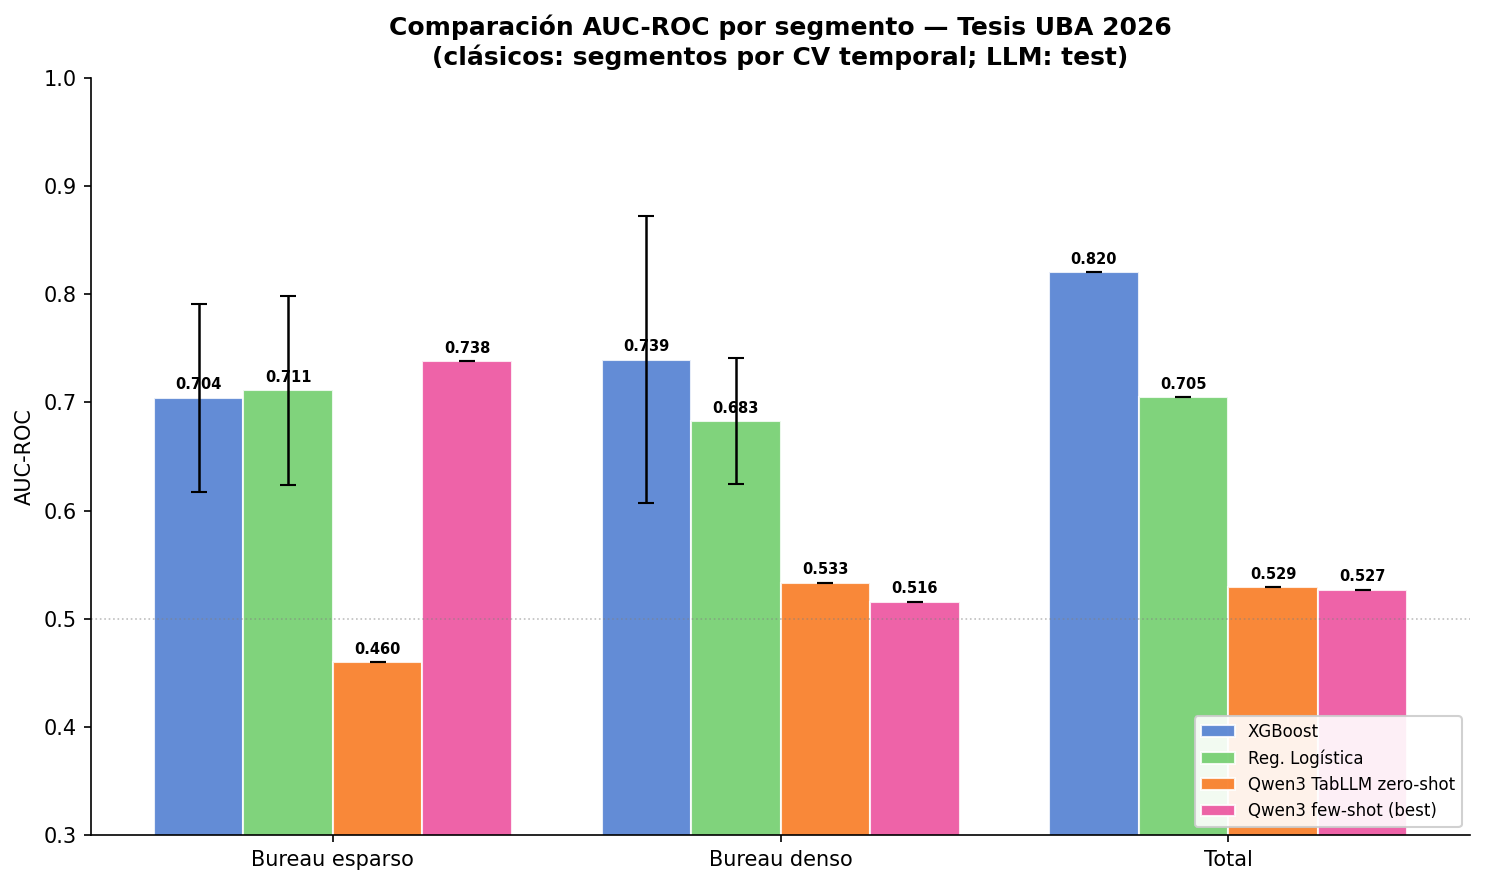

In [3]:
Image(filename=str(BASE / "figures" / "22_comparacion_auc_segmentos.png"))

**Lectura.** A nivel total/denso, XGBoost domina. El interés está en el segmento esparso
(thin-file), donde el few-shot del LLM se acerca y supera a XGBoost — ver notebook 08.